# Resume Screening Regression Model
Notebook ini membuat model regresi untuk memprediksi `match_score` (1-5) antara CV dan Job Description berdasarkan ekstraksi fitur TF-IDF.

In [1]:
# 1. Instalasi Library
!pip install -U pandas numpy scikit-learn xgboost lightgbm matplotlib seaborn nltk scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr
import scipy.sparse as sp

nltk.download('stopwords')
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sayli\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Load Dataset dan Exploratory Data Analysis

Dataset lokal berhasil di-load!

--- Shape Dataset ---
(10000, 3)

--- Missing Values ---
job_description    0
resume             0
match_score        0
dtype: int64

--- Distribusi match_score ---
match_score
1     440
2    1890
3    2269
4    3029
5    2372
Name: count, dtype: int64


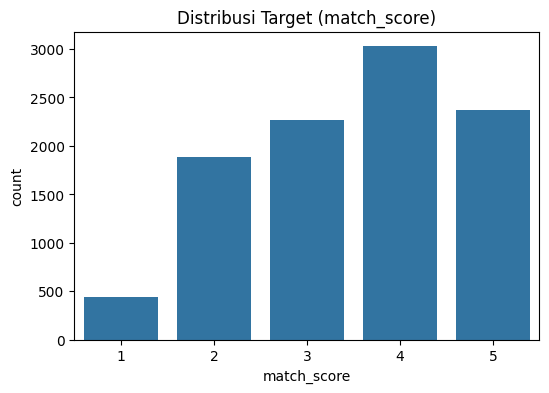

In [3]:
# Asumsi: dataset berada di path berikut atau di-upload ke Colab dengan nama yang sama
file_path = 'NLP_Supervised/resume_job_matching_dataset.csv' # Ubah ke 'resume_job_matching_dataset.csv' jika di Colab
try:
    df = pd.read_csv(file_path)
    print("Dataset berhasil di-load!")
except FileNotFoundError:
    df = pd.read_csv('resume_job_matching_dataset.csv')
    print("Dataset lokal berhasil di-load!")

print("\n--- Shape Dataset ---")
print(df.shape)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Distribusi match_score ---")
print(df['match_score'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
sns.countplot(x='match_score', data=df)
plt.title('Distribusi Target (match_score)')
plt.show()

## 2. Preprocessing Teks

In [4]:
stop_words_en = set(stopwords.words('english'))

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    cleaned_words = [word for word in words if word not in stop_words_en]
    return ' '.join(cleaned_words)

print("Memproses teks...")
df['cleaned_resume'] = df['resume'].apply(clean_text)
df['cleaned_jd'] = df['job_description'].apply(clean_text)
print("Preprocessing selesai.")

Memproses teks...
Preprocessing selesai.


## 3. Ekstraksi Fitur (TF-IDF)
Kita akan membuat vektor TF-IDF untuk resume dan JD, lalu menghitung Cosine Similarity. Kita juga akan menggabungkan vektor TF-IDF sebagai fitur regresi.

In [5]:
print("Ekstraksi TF-IDF...")
# Menggunakan max_features yang tidak terlalu besar agar training regresi lebih ringan
tfidf = TfidfVectorizer(max_features=500)

all_text = df['cleaned_resume'].tolist() + df['cleaned_jd'].tolist()
tfidf.fit(all_text)

resume_tfidf = tfidf.transform(df['cleaned_resume'])
jd_tfidf = tfidf.transform(df['cleaned_jd'])

print("Menghitung Cosine Similarity...")
# Hitung cosine similarity row by row
similarity_scores = np.array([cosine_similarity(resume_tfidf[i], jd_tfidf[i])[0][0] for i in range(resume_tfidf.shape[0])]).reshape(-1, 1)
df['tfidf_sim'] = similarity_scores

# Gabungkan fitur: absolute difference dari TF-IDF + similarity score
# Pendekatan diff vektor terbukti efektif untuk matching context di berbagai referensi
X_diff = abs(resume_tfidf - jd_tfidf)
X = sp.hstack([X_diff, similarity_scores])
y = df['match_score'].values

print("Dimensi Fitur (X):", X.shape)

Ekstraksi TF-IDF...
Menghitung Cosine Similarity...
Dimensi Fitur (X): (10000, 501)


## 4. Modeling Regresi

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
}

results = []

print("Training dan Evaluasi...")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    spearman_corr, _ = spearmanr(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Spearman': spearman_corr
    })

df_results = pd.DataFrame(results)
display(df_results.sort_values(by='Spearman', ascending=False))

Training dan Evaluasi...


,Model,MAE,RMSE,R2,Spearman
3,LightGBM,0.451016,0.587386,0.744396,0.853827
2,XGBoost,0.475522,0.611703,0.722794,0.838190
1,Random Forest,0.516495,0.668745,0.668684,0.806473
0,Linear Regression,0.563282,0.718665,0.617374,0.790731


## 5. Hyperparameter Tuning (LGBMRegressor)
LGBMRegressor biasanya sangat cepat dan efektif untuk data tabular/sparse. Kita akan tuning ringan.

In [12]:
param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0,7, 0.1],
    'max_depth': [10, 15, 20]
}

print("Memulai RandomizedSearchCV untuk LightGBM...")
lgbm = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
random_search = RandomizedSearchCV(lgbm, param_distributions=param_grid, n_iter=10, 
                                   scoring='neg_mean_absolute_error', cv=3, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

print("Parameter Terbaik:", random_search.best_params_)

best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)

print("\n--- Hasil Model Terbaik ---")
print(f"MAE: {mean_absolute_error(y_test, y_pred_best):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best)):.4f}")
print(f"R2: {r2_score(y_test, y_pred_best):.4f}")
spearman_best, _ = spearmanr(y_test, y_pred_best)
print(f"Spearman Corr: {spearman_best:.4f}")

Memulai RandomizedSearchCV untuk LightGBM...
Parameter Terbaik: {'n_estimators': 300, 'max_depth': 20, 'learning_rate': 0.1}

--- Hasil Model Terbaik ---
MAE: 0.4382
RMSE: 0.5680
R2: 0.7610
Spearman Corr: 0.8640


## 6. Visualisasi Prediksi vs Aktual

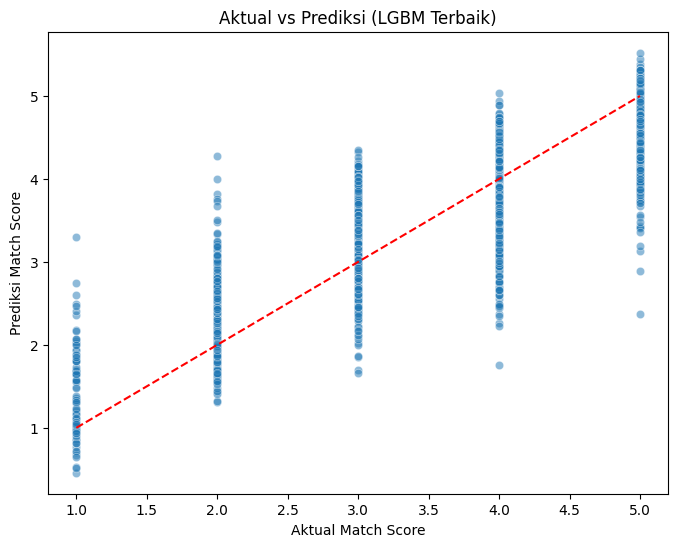

In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.5)
plt.plot([1, 5], [1, 5], color='red', linestyle='--') # Garis ideal
plt.title('Aktual vs Prediksi (LGBM Terbaik)')
plt.xlabel('Aktual Match Score')
plt.ylabel('Prediksi Match Score')
plt.show()

## 7. Kesimpulan dan Rekomendasi

1. **Performa Regresi vs Baseline**: Jika korelasi Spearman menunjukkan nilai positif yang signifikan (mendekati 1) dan R2 positif, maka model regresi belajar menangkap pola ordinal/peringkat lebih baik dibandingkan prediksi rata-rata (baseline).
2. **Kelayakan Dataset**: Model regresi memberikan kemudahan untuk *sorting* (pengurutan NDCG) karena rentang prediksi kontinu (contoh: kandidat berskor prediksi 4.7 akan berada di atas kandidat 4.3). Dataset ini siap dilanjutkan ke pengembangan web.
3. **Saran Perbaikan**: Untuk produksi (*production*), metode representasi teks bisa di-*upgrade* menggunakan *Sentence-BERT (SBERT)* alih-alih *TF-IDF* agar sistem bisa menangkap konteks semantik dari *Job Description* dan *CV*, bukan hanya irisan kemiripan kata (*keyword matching*).